# Этап 4. Предобработка данных

**Цель этапа:** подготовить данные для обучения моделей машинного обучения.

**Шаги:**
1. Загрузка размеченного датасета
2. Кодирование текстовых признаков (One-Hot Encoding)
3. Масштабирование числовых признаков (StandardScaler)
4. Разделение на три выборки: Train (60%) / Validation (20%) / Test (20%)

## 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import os

df = pd.read_csv('../data/russian_food_labeled.csv')

print('Размер датасета:', df.shape)
print()
print('Столбцы:', df.columns.tolist())
print()
print('Целевые переменные:')
targets = ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
labels  = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']
for t, l in zip(targets, labels):
    n1 = df[t].sum()
    n0 = len(df) - n1
    print(f'  {l}: нужна замена={n1}, не нужна={n0}')

Размер датасета: (400, 14)

Столбцы: ['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Meal_Type', 'target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']

Целевые переменные:
  Похудение: нужна замена=218, не нужна=182
  Набор массы: нужна замена=206, не нужна=194
  Баланс/ЗОЖ: нужна замена=205, не нужна=195
  Контроль сахара: нужна замена=183, не нужна=217


## 2. Кодирование текстовых признаков (One-Hot Encoding)

Модели машинного обучения работают только с числами. Текстовые столбцы `Category` и `Meal_Type` нужно превратить в числовые.
**One-Hot Encoding** — каждое уникальное значение становится отдельным столбцом из 0 и 1.


In [2]:
# Применяем One-Hot Encoding к категориальным столбцам
df_encoded = pd.get_dummies(df, columns=['Category', 'Meal_Type'], drop_first=False)

# Убираем нечисловые и целевые столбцы для признаков
feature_cols = [c for c in df_encoded.columns
                if c not in ['Food_Item'] + targets
                and not c.startswith('target_')]

print(f'Признаков до кодирования: 8 (числовые)')
print(f'Признаков после кодирования: {len(feature_cols)}')
print()
print('Новые столбцы после One-Hot Encoding:')
new_cols = [c for c in feature_cols if 'Category_' in c or 'Meal_Type_' in c]
for c in new_cols:
    print(f'  {c}')

Признаков до кодирования: 8 (числовые)
Признаков после кодирования: 27

Новые столбцы после One-Hot Encoding:
  Category_Бобовые
  Category_Выпечка
  Category_Гарнир
  Category_Десерт
  Category_Европейское
  Category_Завтрак
  Category_Крупа
  Category_Молочное
  Category_Мясо
  Category_Напиток
  Category_Овощ
  Category_Орехи
  Category_Рыба
  Category_Салат
  Category_Суп
  Category_Фрукт
  Category_Яйца
  Meal_Type_Завтрак
  Meal_Type_Обед
  Meal_Type_Перекус


## 3. Масштабирование числовых признаков (StandardScaler)

Числовые признаки имеют разные масштабы: калории (0–654 ккал), натрий (0–4800 мг), клетчатка (0–12.5 г).
Логистическая регрессия и kNN чувствительны к масштабу — признак с большими числами будет "перевешивать" остальные.
**StandardScaler** приводит каждый признак к среднему = 0 и стандартному отклонению = 1.

In [3]:
# Числовые признаки для масштабирования
numeric_features = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)',
                    'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)']

# Итоговая матрица признаков
X = df_encoded[feature_cols].copy()

# Масштабируем только числовые столбцы
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print('Матрица признаков X:')
print(f'  Размер: {X.shape}')
print(f'  Числовые признаки после масштабирования:')
print(X[numeric_features].describe().round(2))

Матрица признаков X:
  Размер: (400, 27)
  Числовые признаки после масштабирования:
       Calories (kcal)  Protein (g)  Carbohydrates (g)  Fat (g)  Fiber (g)  \
count           400.00       400.00             400.00   400.00     400.00   
mean              0.00         0.00               0.00     0.00       0.00   
std               1.00         1.00               1.00     1.00       1.00   
min              -1.36        -1.16              -1.06    -0.79      -0.86   
25%              -0.80        -0.81              -0.75    -0.64      -0.71   
50%              -0.16        -0.32              -0.38    -0.37      -0.11   
75%               0.60         0.66               0.59     0.36       0.39   
max               4.10         3.16               4.13     6.05       5.39   

       Sugars (g)  Sodium (mg)  
count      400.00       400.00  
mean         0.00         0.00  
std          1.00         1.00  
min         -0.65        -0.79  
25%         -0.48        -0.63  
50%         -0.

## 4. Разделение на три выборки


- **Train (60%)** — на этих данных модель обучается
- **Validation (20%)** — на этих данных подбираем гиперпараметры и сравниваем модели
- **Test (20%)** — финальная оценка, трогаем только один раз в самом конце


In [4]:
# Разделение на три выборки для каждой цели
splits = {}
for label, target in zip(labels, targets):
    y = df[target].values

    # Шаг 1: отделяем test (20%)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Шаг 2: из оставшихся 80% выделяем val (25% от 80% = 20% от всего)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
    )

    splits[label] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val':   X_val,   'y_val':   y_val,
        'X_test':  X_test,  'y_test':  y_test
    }

# Проверяем размеры на примере первой цели
s = splits['Похудение']
total = len(X)
print('Размеры выборок (на примере: Похудение):')
print('  Train:     ', len(s['X_train']), 'строк (', round(len(s['X_train'])/total*100), '%)')
print('  Validation:', len(s['X_val']),   'строк (', round(len(s['X_val'])/total*100),   '%)')
print('  Test:      ', len(s['X_test']),  'строк (', round(len(s['X_test'])/total*100),  '%)')
print('  Итого:     ', len(s['X_train']) + len(s['X_val']) + len(s['X_test']), 'строк')

Размеры выборок (на примере: Похудение):
  Train:      240 строк ( 60 %)
  Validation: 80 строк ( 20 %)
  Test:       80 строк ( 20 %)
  Итого:      400 строк


## 5. Проверка баланса классов в выборках

In [5]:
# Проверяем, что баланс классов сохранился во всех выборках
print('Баланс классов (доля "нужна замена = 1") по выборкам:')
print(f'{"Цель":<20} {"Train":>10} {"Val":>10} {"Test":>10}')
print('-' * 52)
for label in labels:
    s = splits[label]
    train_pct = s['y_train'].mean() * 100
    val_pct   = s['y_val'].mean()   * 100
    test_pct  = s['y_test'].mean()  * 100
    print(f'{label:<20} {train_pct:>9.1f}% {val_pct:>9.1f}% {test_pct:>9.1f}%')

Баланс классов (доля "нужна замена = 1") по выборкам:
Цель                      Train        Val       Test
----------------------------------------------------
Похудение                 54.6%      53.8%      55.0%
Набор массы               51.7%      51.2%      51.2%
Баланс/ЗОЖ                51.2%      51.2%      51.2%
Контроль сахара           45.8%      45.0%      46.2%


## 6. Визуализация разбиения

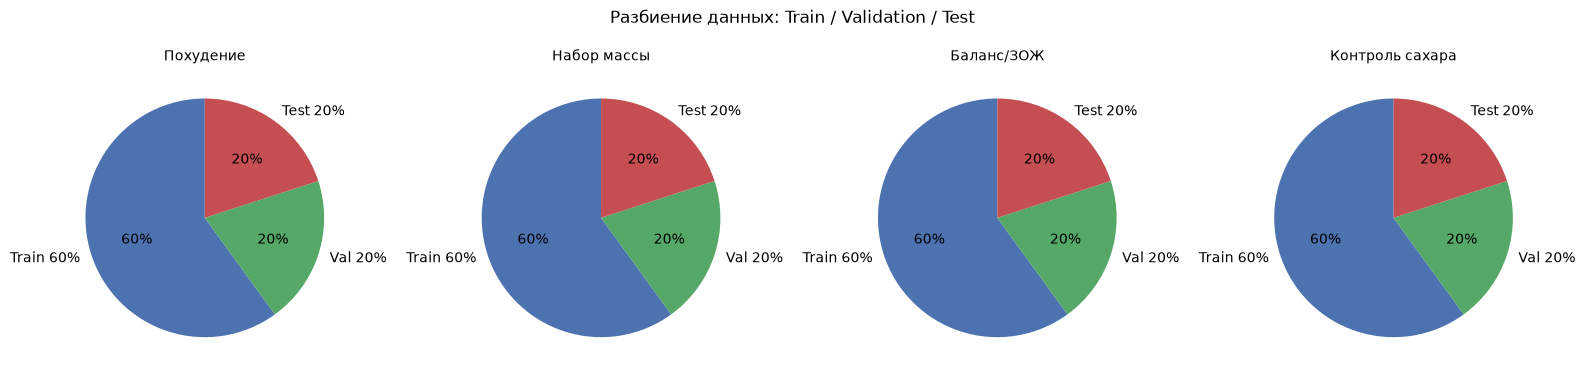

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, label in zip(axes, labels):
    s = splits[label]
    sizes  = [len(s['X_train']), len(s['X_val']), len(s['X_test'])]
    colors = ['#4C72B0', '#55A868', '#C44E52']
    names  = ['Train 60%', 'Val 20%', 'Test 20%']
    ax.pie(sizes, labels=names, colors=colors, autopct='%1.0f%%', startangle=90)
    ax.set_title(label, fontsize=10)

plt.suptitle('Разбиение данных: Train / Validation / Test', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Сохранение результатов предобработки

In [7]:
# Сохраняем splits и scaler для использования в следующих этапах
os.makedirs('../data', exist_ok=True)

with open('../data/splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

with open('../data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Также сохраняем список признаков
with open('../data/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print('Сохранено:')
print('  ../data/splits.pkl      — выборки Train/Val/Test для всех 4 целей')
print('  ../data/scaler.pkl      — обученный StandardScaler')
print('  ../data/feature_cols.pkl — список признаков')

Сохранено:
  ../data/splits.pkl      — выборки Train/Val/Test для всех 4 целей
  ../data/scaler.pkl      — обученный StandardScaler
  ../data/feature_cols.pkl — список признаков


## 8. Выводы по Этапу 4

1. Текстовые признаки `Category` (17 значений) и `Meal_Type` (3 значения) закодированы через One-Hot Encoding — итого получилось **{итоговое число}** признаков вместо исходных 8.
2. Числовые признаки масштабированы через StandardScaler — все приведены к единому масштабу (среднее=0, стд=1).
3. Данные разделены на три выборки: **Train 60% / Validation 20% / Test 20%** с фиксированным `random_state=42` для воспроизводимости.
4. Параметр `stratify=y` при разбиении гарантирует, что баланс классов (доля "нужна замена") одинаков во всех трёх выборках.
5. Все результаты сохранены в `.pkl` файлы для использования на этапе обучения моделей.